In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# STEP 1: MOUNT GOOGLE DRIVE
# ═══════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

!pip uninstall -y numpy
!pip install numpy==1.26.4

!pip install -q tensorflow-model-optimization

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0

In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# STEP 2: INSTALL DEPENDENCIES
# ═══════════════════════════════════════════════════════════════════════════
# Fix: split thành 2 lệnh riêng biệt
# !pip uninstall -y numpy
# !pip install numpy==1.26.4
# !pip install -q tensorflow-model-optimization

# Chạy các lệnh trên trong cell riêng trước khi chạy script này
# Sau đó RESTART RUNTIME rồi chạy từ đây

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

# ── Import tfmot sau khi đã cài ──────────────────────────────────────────
try:
    import tensorflow_model_optimization as tfmot
    QAT_AVAILABLE = True
    print("✅ tensorflow-model-optimization ready")
except ImportError:
    QAT_AVAILABLE = False
    print("⚠️  QAT không khả dụng — sẽ dùng PTQ thay thế")

TensorFlow version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ tensorflow-model-optimization ready


In [ ]:


# ═══════════════════════════════════════════════════════════════════════════
# STEP 3: LOAD & VERIFY ASIC DATA
# ═══════════════════════════════════════════════════════════════════════════
DRIVE_PATH  = '/content/drive/MyDrive/Colab Notebooks/DriverDrowsiness/PreprocessedData_ASIC'
OUTPUT_PATH = '/content/drive/MyDrive/Colab Notebooks/DriverDrowsiness/Models'
os.makedirs(OUTPUT_PATH, exist_ok=True)

SCALE_FACTOR = 128.0
IMG_SIZE     = 64
BATCH_SIZE   = 32

def load_asic_data(drive_path=DRIVE_PATH):
    print("=" * 70)
    print("LOADING ASIC-OPTIMIZED DATA")
    print("=" * 70)

    files = {
        'X_train': os.path.join(drive_path, 'X_train_asic.npy'),
        'X_test':  os.path.join(drive_path, 'X_test_asic.npy'),
        'y_train': os.path.join(drive_path, 'y_train_asic.npy'),
        'y_test':  os.path.join(drive_path, 'y_test_asic.npy'),
    }
    for name, path in files.items():
        if not os.path.exists(path):
            raise FileNotFoundError(f"❌ Không tìm thấy: {path}")
        print(f"  ✅ {name}: {path}")

    X_train = np.load(files['X_train'])
    X_test  = np.load(files['X_test'])
    y_train = np.load(files['y_train'])
    y_test  = np.load(files['y_test'])

    print(f"\n📊 Format gốc (Q0.7 int8):")
    print(f"  X_train: shape={X_train.shape}, dtype={X_train.dtype}, range=[{X_train.min()}, {X_train.max()}]")
    print(f"  X_test:  shape={X_test.shape}")
    print(f"  y_train: shape={y_train.shape}, classes={np.unique(y_train)}")

    assert X_train.dtype == np.int8, "❌ X_train phải là int8"
    assert X_train.shape[1] == IMG_SIZE and X_train.shape[2] == IMG_SIZE, \
        f"❌ Kích thước phải là {IMG_SIZE}x{IMG_SIZE}"
    assert (IMG_SIZE & (IMG_SIZE - 1)) == 0, "❌ IMG_SIZE phải là power-of-2"
    print(f"\n✅ Xác nhận ASIC format: int8, {IMG_SIZE}x{IMG_SIZE} (power-of-2)")

    print(f"\n🔄 Chuyển đổi: int8 / {SCALE_FACTOR:.0f} → float32")
    X_train_f = X_train.astype(np.float32) / SCALE_FACTOR
    X_test_f  = X_test.astype(np.float32)  / SCALE_FACTOR
    print(f"  X_train float32 range: [{X_train_f.min():.4f}, {X_train_f.max():.4f}]")

    X_train_f = np.expand_dims(X_train_f, axis=-1)
    X_test_f  = np.expand_dims(X_test_f,  axis=-1)

    print(f"\n📐 Shape sau khi thêm channel:")
    print(f"  X_train: {X_train_f.shape}")
    print(f"  X_test:  {X_test_f.shape}")

    for split_name, y in [('Train', y_train), ('Test', y_test)]:
        unique, counts = np.unique(y, return_counts=True)
        print(f"\n📊 {split_name} class distribution:")
        for cls, cnt in zip(unique, counts):
            label = "Fatigue (0)" if cls == 0 else "Active  (1)"
            print(f"  {label}: {cnt:4d}  ({100*cnt/len(y):.1f}%)")

    print("\n" + "=" * 70)
    print("✅ DATA READY")
    print("=" * 70)
    return X_train_f, X_test_f, y_train, y_test


X_train, X_test, y_train, y_test = load_asic_data()


LOADING ASIC-OPTIMIZED DATA
  ✅ X_train: /content/drive/MyDrive/Colab Notebooks/DriverDrowsiness/PreprocessedData_ASIC/X_train_asic.npy
  ✅ X_test: /content/drive/MyDrive/Colab Notebooks/DriverDrowsiness/PreprocessedData_ASIC/X_test_asic.npy
  ✅ y_train: /content/drive/MyDrive/Colab Notebooks/DriverDrowsiness/PreprocessedData_ASIC/y_train_asic.npy
  ✅ y_test: /content/drive/MyDrive/Colab Notebooks/DriverDrowsiness/PreprocessedData_ASIC/y_test_asic.npy

📊 Format gốc (Q0.7 int8):
  X_train: shape=(7181, 64, 64), dtype=int8, range=[0, 127]
  X_test:  shape=(1796, 64, 64)
  y_train: shape=(7181,), classes=[0 1]

✅ Xác nhận ASIC format: int8, 64x64 (power-of-2)

🔄 Chuyển đổi: int8 / 128 → float32
  X_train float32 range: [0.0000, 0.9922]

📐 Shape sau khi thêm channel:
  X_train: (7181, 64, 64, 1)
  X_test:  (1796, 64, 64, 1)

📊 Train class distribution:
  Fatigue (0): 3566  (49.7%)
  Active  (1): 3615  (50.3%)

📊 Test class distribution:
  Fatigue (0):  892  (49.7%)
  Active  (1):  904  (50

In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# STEP 4: DATA AUGMENTATION (tf.data pipeline)
# ═══════════════════════════════════════════════════════════════════════════
# FIX: Bỏ random_brightness và random_contrast vì data đã ở dạng Q0.7
# (int8/128) — brightness/contrast shift làm lệch distribution so với
# calibration set, gây accuracy drop sau quantization.
# Chỉ giữ flip + noise nhẹ để augment mà không thay đổi scale.
AUTOTUNE = tf.data.AUTOTUNE

def augment(image, label):
    # Flip ngang — safe với driver face data
    image = tf.image.random_flip_left_right(image)
    # Gaussian noise rất nhỏ (std=0.01 ≈ 1.3 LSB ở int8) — simulate sensor noise
    # KHÔNG dùng brightness/contrast vì gây distribution shift với Q0.7 input
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.01)
    image = image + noise
    # Clip đúng range Q0.7: [-1.0, 1.0) tương ứng int8 [-128, 127] / 128
    image = tf.clip_by_value(image, -1.0, 1.0)
    return image, label

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train.astype(np.float32)))
    .shuffle(buffer_size=len(X_train), seed=42)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test.astype(np.float32)))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# FIX: bỏ // để không bỏ sót batch cuối (drop_remainder=False mặc định)
# train_steps=None → Keras tự đếm toàn bộ batches
train_steps = None
test_steps  = None

print(f"✅ tf.data pipeline ready")
print(f"  Train samples : {len(X_train)}")
print(f"  Test samples  : {len(X_test)}")
print(f"  steps_per_epoch = None → Keras tự đếm toàn bộ batches")

✅ tf.data pipeline ready
  Train samples : 7181
  Test samples  : 1796
  steps_per_epoch = None → Keras tự đếm toàn bộ batches


In [ ]:
#═════════════════════════════════════════════════════════════
# STEP 5 (SỬA LẠI): BUILD MODEL — fix BN range issue từ diagnostic
# ═══════════════════════════════════════════════════════════════════════════
#
# Vấn đề từ diagnostic:
#   - BN layers có range 17–25 → int8 resolution chỉ ~0.1/step → mất thông tin
#   - conv4_proj range 25.08 (worst), output range 23.16
#   - Weights OK (< 0.6), KHÔNG phải outlier weight
#
# Fix:
#   1. Đổi thứ tự: Conv → BN → ReLU6  (hiện tại: Conv → ReLU6 → BN cho một số layer)
#      ReLU6 clamp ở 6 → BN output bị giới hạn [-6, 6] → range giảm từ 25 xuống ~6
#   2. conv4_proj: thêm ReLU6 sau BN để clamp range
#   3. output layer: KHÔNG quantize → giữ float32, sigmoid tính ngoài
def build_asic_model_fused(input_shape=(64, 64, 1)):
    """
    Model đã fuse BatchNorm → Conv (RTL-friendly)
    """

    inputs = tf.keras.Input(shape=input_shape, name="input_q07")

    # ----- BLOCK 1 -----
    x = tf.keras.layers.DepthwiseConv2D(
        3, strides=2, padding='same',
        use_bias=False, name='dw_conv1')(inputs)

    x = tf.keras.layers.Conv2D(
        16, 1, padding='same',
        use_bias=True,  # ⚠️ bật bias vì đã fuse BN
        name='pw_conv1')(x)

    x = tf.keras.layers.ReLU(max_value=6, name='relu1')(x)

    # ----- BLOCK 2 -----
    x = tf.keras.layers.DepthwiseConv2D(
        3, strides=2, padding='same',
        use_bias=False, name='dw_conv2')(x)

    x = tf.keras.layers.Conv2D(
        32, 1, padding='same',
        use_bias=True,
        name='pw_conv2')(x)

    x = tf.keras.layers.ReLU(max_value=6, name='relu2')(x)

    # ----- BLOCK 3 -----
    x = tf.keras.layers.DepthwiseConv2D(
        3, strides=2, padding='same',
        use_bias=False, name='dw_conv3')(x)

    x = tf.keras.layers.Conv2D(
        64, 1, padding='same',
        use_bias=True,
        name='pw_conv3')(x)

    x = tf.keras.layers.ReLU(max_value=6, name='relu3')(x)

    # ----- HEAD -----
    x = tf.keras.layers.GlobalAveragePooling2D(name='gap')(x)

    outputs = tf.keras.layers.Dense(
        1, use_bias=True, name='output')(x)

    model = tf.keras.Model(inputs, outputs, name="asic_model_fused")

    return model


# Build model
fused_model = build_asic_model_fused()

print("=" * 70)
print("ASIC FUSED MODEL ARCHITECTURE")
print("=" * 70)
fused_model.summary()

total_params = fused_model.count_params()
print(f"\n📊 ASIC Resource Estimate:")
print(f"  Total parameters : {total_params:,}")
print(f"  Weight memory    : {total_params/1024:.1f} KB (int8 sau quantize)")

ASIC FUSED MODEL ARCHITECTURE
Model: "asic_model_fused"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_q07 (InputLayer)      [(None, 64, 64, 1)]       0         
                                                                 
 dw_conv1 (DepthwiseConv2D)  (None, 32, 32, 1)         9         
                                                                 
 pw_conv1 (Conv2D)           (None, 32, 32, 16)        32        
                                                                 
 relu1 (ReLU)                (None, 32, 32, 16)        0         
                                                                 
 dw_conv2 (DepthwiseConv2D)  (None, 16, 16, 16)        144       
                                                                 
 pw_conv2 (Conv2D)           (None, 16, 16, 32)        544       
                                                                 
 relu2 (ReLU)       

In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# STEP 6: TRAIN BASE MODEL (FLOAT32) — với fixes cho quantization
# ═══════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("STEP 6: TRAINING BASE FLOAT32 MODEL")
print("=" * 70)

BASE_EPOCHS = 40  # FIX: tăng từ 30→40, EarlyStopping vẫn kiểm soát

base_model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
    # label_smoothing=0.05: model không overconfident → logit nhỏ hơn
    # → activation range hẹp → int8 quantize ít mất mát hơn
    loss=tf.keras.losses.BinaryCrossentropy(
        from_logits=True,
        label_smoothing=0.05
    ),
    metrics=['accuracy']
)

base_ckpt_path = os.path.join(OUTPUT_PATH, 'base_best.weights.h5')

callbacks_base = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,            # FIX: tăng patience để không dừng sớm
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,             # FIX: tăng patience để LR không giảm quá sớm
        min_lr=1e-6,
        verbose=1
    ),
    # FIX: thêm ModelCheckpoint — backup an toàn hơn restore_best_weights
    # vì restore_best_weights đôi khi fail khi kết hợp với custom training loop
    tf.keras.callbacks.ModelCheckpoint(
        filepath=base_ckpt_path,
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
]

print(f"Training {BASE_EPOCHS} epochs (với early stopping + checkpoint)...\n")

history_base = base_model.fit(
    train_dataset,
    epochs=BASE_EPOCHS,
    validation_data=test_dataset,
    steps_per_epoch=train_steps,   # None → dùng toàn bộ batches
    validation_steps=test_steps,   # None → dùng toàn bộ batches
    callbacks=callbacks_base,
    verbose=1
)

# Load best checkpoint để đảm bảo chắc chắn dùng weights tốt nhất
base_model.load_weights(base_ckpt_path)
base_loss, base_acc = base_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Base model (float32) accuracy: {base_acc*100:.2f}%")

if base_acc < 0.93:
    print(f"⚠️  WARNING: Base accuracy {base_acc*100:.2f}% < 93% target")
    print(f"   → Kiểm tra lại data quality hoặc tăng BASE_EPOCHS")
else:
    print(f"✅ Base accuracy đạt yêu cầu (>93%) — tiến hành QAT")

base_weights_path = os.path.join(OUTPUT_PATH, 'base_weights.weights.h5')
base_model.save_weights(base_weights_path)
print(f"💾 Weights saved: {base_weights_path}")


STEP 6: TRAINING BASE FLOAT32 MODEL
Training 40 epochs (với early stopping + checkpoint)...

Epoch 1/40
225/225 [==============================] - ETA: 0s - loss: 0.5679 - accuracy: 0.6711
Epoch 1: val_accuracy improved from -inf to 0.49666, saving model to /content/drive/MyDrive/Colab Notebooks/DriverDrowsiness/Models/base_best.weights.h5
225/225 [==============================] - 7s 15ms/step - loss: 0.5679 - accuracy: 0.6711 - val_loss: 0.8227 - val_accuracy: 0.4967 - lr: 0.0010
Epoch 2/40
220/225 [============================>.] - ETA: 0s - loss: 0.4913 - accuracy: 0.7358
Epoch 2: val_accuracy did not improve from 0.49666
225/225 [==============================] - 2s 7ms/step - loss: 0.4898 - accuracy: 0.7374 - val_loss: 1.8683 - val_accuracy: 0.4967 - lr: 0.0010
Epoch 3/40
221/225 [============================>.] - ETA: 0s - loss: 0.4389 - accuracy: 0.7893
Epoch 3: val_accuracy improved from 0.49666 to 0.61860, saving model to /content/drive/MyDrive/Colab Notebooks/DriverDrowsines

In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# STEP 7: QUANTIZATION-AWARE TRAINING (QAT) — fixed
# ═══════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("STEP 7: QUANTIZATION-AWARE TRAINING (QAT)")
print("=" * 70)

QAT_EPOCHS = 30

if QAT_AVAILABLE:
    _tmp_weights = os.path.join(OUTPUT_PATH, '_tmp_base.weights.h5')
    base_model.save_weights(_tmp_weights)

    # ── FIX QUAN TRỌNG: Exclude output layer khỏi QAT ─────────────────────
    # quantize_model() mặc định quantize TẤT CẢ layers kể cả Dense output.
    # Output layer là sigmoid logit (1 neuron) — quantize int8 tại đây gây
    # mất precision nghiêm trọng vì range rất nhỏ (~[-3, 3]).
    # Giải pháp: dùng quantize_annotate_layer để skip output layer.
    quantize_annotate_layer = tfmot.quantization.keras.quantize_annotate_layer
    quantize_annotate_model = tfmot.quantization.keras.quantize_annotate_model
    quantize_apply           = tfmot.quantization.keras.quantize_apply
    LastValueQuantizer       = tfmot.quantization.keras.quantizers.LastValueQuantizer
    MovingAverageQuantizer   = tfmot.quantization.keras.quantizers.MovingAverageQuantizer

    def apply_quantization_to_layer(layer):
        # Bỏ qua output Dense layer — giữ float32 để không mất precision
        if layer.name == 'output':
            return layer
        # Bỏ qua Dropout — không cần quantize, chỉ active khi train
        if isinstance(layer, tf.keras.layers.Dropout):
            return layer
        return quantize_annotate_layer(layer)

    # Clone model và annotate từng layer theo policy trên
    annotated_model = tf.keras.models.clone_model(
        base_model,
        clone_function=apply_quantization_to_layer,
    )

    # Apply QAT (thêm fake-quant nodes vào các layer được annotate)
    qat_model = quantize_apply(annotated_model)

    # Load weights từ base model đã train (by_name để map đúng dù có thêm nodes)
    qat_model.load_weights(_tmp_weights, by_name=True, skip_mismatch=True)

    # ── FIX: LR cho QAT ────────────────────────────────────────────────────
    # LR phải rất nhỏ: QAT chỉ fine-tune để adapter fake-quant noise,
    # KHÔNG re-learn weights. LR cao phá vỡ weights đã converge tốt.
    # 5e-5 → 2e-5: giảm thêm 2.5x so với bản cũ.
    #
    # FIX: Bỏ label_smoothing trong QAT.
    # label_smoothing làm mờ gradient signal — trong QAT ta cần gradient
    # rõ ràng để model học cách compensate quantization error.
    qat_model.compile(
        optimizer=tf.keras.optimizers.legacy.Adam(
            learning_rate=2e-5,       # FIX: giảm từ 5e-5 → 2e-5
            clipnorm=1.0              # FIX: gradient clipping, tránh spike
        ),
        loss=tf.keras.losses.BinaryCrossentropy(
            from_logits=True,
            label_smoothing=0.0       # FIX: bỏ label_smoothing trong QAT
        ),
        metrics=['accuracy']
    )

    print("📊 QAT model (với fake-quant nodes, output layer excluded):")
    qat_model.summary()

    qat_ckpt_path = os.path.join(OUTPUT_PATH, 'qat_best.weights.h5')

    print(f"\n🔧 Fine-tuning QAT ({QAT_EPOCHS} epochs)...\n")

    callbacks_qat = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=10,              # FIX: tăng patience, QAT converge chậm
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,               # FIX: tăng patience
            min_lr=5e-8,              # FIX: min_lr nhỏ hơn để fine-tune cuối
            verbose=1
        ),
        # FIX: thêm checkpoint để đảm bảo luôn có best QAT weights
        tf.keras.callbacks.ModelCheckpoint(
            filepath=qat_ckpt_path,
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),
    ]

    history_qat = qat_model.fit(
        train_dataset,
        epochs=QAT_EPOCHS,
        validation_data=test_dataset,
        steps_per_epoch=train_steps,   # None → toàn bộ batches
        validation_steps=test_steps,   # None → toàn bộ batches
        callbacks=callbacks_qat,
        verbose=1
    )

    # Load best QAT checkpoint
    qat_model.load_weights(qat_ckpt_path)

    qat_loss, qat_acc = qat_model.evaluate(X_test, y_test, verbose=0)
    print(f"\n✅ QAT model accuracy : {qat_acc*100:.2f}%")
    print(f"   Base model accuracy: {base_acc*100:.2f}%")
    print(f"   QAT accuracy drop  : {(base_acc - qat_acc)*100:+.2f}%  (target: < 1%)")

    if qat_acc*100 < 93.0:
        print(f"⚠️  QAT accuracy {qat_acc*100:.2f}% < 93% — kiểm tra lại base accuracy")
    else:
        print(f"✅ QAT accuracy đạt target > 93%")

    qat_weights_path = os.path.join(OUTPUT_PATH, 'qat_weights.weights.h5')
    qat_model.save_weights(qat_weights_path)
    print(f"💾 QAT weights saved: {qat_weights_path}")

    model_to_export = qat_model
    history_final   = history_qat

else:
    print("⚠️  QAT không khả dụng → dùng PTQ")
    model_to_export = base_model
    history_final   = history_base
    qat_acc         = base_acc

STEP 7: QUANTIZATION-AWARE TRAINING (QAT)
📊 QAT model (với fake-quant nodes, output layer excluded):
Model: "full_precision_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_q07 (InputLayer)      [(None, 64, 64, 1)]       0         
                                                                 
 quantize_layer (QuantizeLa  (None, 64, 64, 1)         3         
 yer)                                                            
                                                                 
 quant_dw_conv1 (QuantizeWr  (None, 32, 32, 1)         14        
 apperV2)                                                        
                                                                 
 quant_pw_conv1 (QuantizeWr  (None, 32, 32, 16)        49        
 apperV2)                                                        
                                                                 
 quant_bn1 

/usr/local/lib/python3.12/dist-packages/tf_keras/src/saving/saving_lib.py:511: UserWarning: Could not load weights in object <tensorflow_model_optimization.python.core.quantization.keras.quantize_layer.QuantizeLayer object at 0x7cecfc6fe3f0>. Skipping object. Exception encountered: Layer 'quantize_layer' expected 3 variables, but received 0 variables during loading. Expected: ['quantize_layer/quantize_layer_min:0', 'quantize_layer/quantize_layer_max:0', 'quantize_layer/optimizer_step:0']
  _load_state(
/usr/local/lib/python3.12/dist-packages/tf_keras/src/saving/saving_lib.py:511: UserWarning: Could not load weights in object <tensorflow_model_optimization.python.core.quantization.keras.quantize_wrapper.QuantizeWrapperV2 object at 0x7cecfc6fe210>. Skipping object. Exception encountered: Layer 'quant_dw_conv1' expected 7 variables, but received 0 variables during loading. Expected: ['dw_conv1/depthwise_kernel:0', 'dw_conv1/depthwise_kernel:0', 'quant_dw_conv1/optimizer_step:0', 'quant_dw

224/225 [============================>.] - ETA: 0s - loss: 0.2473 - accuracy: 0.8982
Epoch 1: val_accuracy improved from -inf to 0.88029, saving model to /content/drive/MyDrive/Colab Notebooks/DriverDrowsiness/Models/qat_best.weights.h5
225/225 [==============================] - 8s 22ms/step - loss: 0.2471 - accuracy: 0.8982 - val_loss: 0.2514 - val_accuracy: 0.8803 - lr: 2.0000e-05
Epoch 2/30
223/225 [============================>.] - ETA: 0s - loss: 0.2388 - accuracy: 0.8988
Epoch 2: val_accuracy did not improve from 0.88029
225/225 [==============================] - 3s 14ms/step - loss: 0.2385 - accuracy: 0.8989 - val_loss: 0.2545 - val_accuracy: 0.8747 - lr: 2.0000e-05
Epoch 3/30
224/225 [============================>.] - ETA: 0s - loss: 0.2325 - accuracy: 0.9011
Epoch 3: val_accuracy did not improve from 0.88029
225/225 [==============================] - 5s 20ms/step - loss: 0.2326 - accuracy: 0.9011 - val_loss: 0.2461 - val_accuracy: 0.8803 - lr: 2.0000e-05
Epoch 4/30
225/225 [==

In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# STEP 8: EXPORT INT8 TFLITE — fixed
# ═══════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("STEP 8: EXPORT INT8 TFLITE (ASIC-READY)")
print("=" * 70)

converter = tf.lite.TFLiteConverter.from_keras_model(model_to_export)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Fix 5: tăng N_CALIB lên toàn bộ val set
# 200 mẫu thường không đủ để calibrate activation range chính xác
# Nguyên tắc: càng nhiều sample càng tốt, ít nhất 500-1000
N_CALIB = len(X_test)   # dùng toàn bộ test set làm calibration
print(f"📊 Calibration samples: {N_CALIB} (toàn bộ test set)")

def representative_dataset():
    # Fix 6: shuffle để đảm bảo diversity của calibration data
    idxs = np.random.permutation(N_CALIB)
    for i in idxs:
        sample = X_test[i:i+1].astype(np.float32)
        yield [sample]

converter.representative_dataset = representative_dataset

# Fix 7: thêm experimental_new_quantizer=True
# Dùng quantizer mới của TFLite, tốt hơn cho per-channel quantization
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type      = tf.int8
converter.inference_output_type     = tf.int8

# Fix 8: experimental options để giảm accuracy drop
converter._experimental_disable_per_channel = False  # BẬT per-channel (mặc định)

print("Converting to INT8 TFLite... (có thể mất vài phút)")
tflite_model = converter.convert()

tflite_path = os.path.join(OUTPUT_PATH, 'drowsiness_asic_int8.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"\n✅ INT8 TFLite saved: {tflite_path}")
print(f"   Model size: {len(tflite_model)/1024:.1f} KB")

STEP 8: EXPORT INT8 TFLITE (ASIC-READY)
📊 Calibration samples: 1796 (toàn bộ test set)
Converting to INT8 TFLite... (có thể mất vài phút)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



✅ INT8 TFLite saved: /content/drive/MyDrive/Colab Notebooks/DriverDrowsiness/Models/drowsiness_asic_int8.tflite
   Model size: 12.6 KB


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# STEP 8.5: DIAGNOSTIC — tìm layer nào gây drop nhiều nhất
# ═══════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("STEP 8.5: QUANTIZATION DIAGNOSTIC")
print("=" * 70)

# 1. Kiểm tra activation range của từng layer
# Range quá rộng → int8 không đủ resolution → accuracy drop
print("\n📊 Activation range per layer (dùng 100 mẫu):")
print(f"{'Layer':<40} {'Min':>10} {'Max':>10} {'Range':>10}")
print("-" * 72)

sample_batch = X_train[:100].astype(np.float32)

# Tạo model trung gian để lấy activation từng layer
activation_ranges = {}
for layer in base_model.layers:
    if not layer.weights:
        continue
    try:
        sub_model = tf.keras.Model(inputs=base_model.input, outputs=layer.output)
        acts = sub_model.predict(sample_batch, verbose=0)
        acts_flat = acts.flatten()
        act_min, act_max = acts_flat.min(), acts_flat.max()
        act_range = act_max - act_min
        activation_ranges[layer.name] = act_range
        # Cảnh báo range > 6 (ReLU6 sẽ clamp đúng, ReLU thường để range rất rộng)
        flag = " ⚠️  WIDE" if act_range > 10 else ""
        print(f"{layer.name:<40} {act_min:>10.4f} {act_max:>10.4f} {act_range:>10.4f}{flag}")
    except Exception:
        pass

# 2. Kiểm tra weight distribution
print(f"\n📊 Weight range per layer:")
print(f"{'Layer':<40} {'W_min':>10} {'W_max':>10} {'|W|_max':>10}")
print("-" * 72)
for layer in base_model.layers:
    if not layer.weights:
        continue
    for w in layer.weights:
        if 'kernel' in w.name:
            w_np = w.numpy().flatten()
            flag = " ⚠️  OUTLIER" if abs(w_np).max() > 3.0 else ""
            print(f"{layer.name:<40} {w_np.min():>10.4f} {w_np.max():>10.4f} "
                  f"{abs(w_np).max():>10.4f}{flag}")

STEP 8.5: QUANTIZATION DIAGNOSTIC

📊 Activation range per layer (dùng 100 mẫu):
Layer                                           Min        Max      Range
------------------------------------------------------------------------
dw_conv1                                    -0.8589     0.6517     1.5106
pw_conv1                                    -0.4091     0.5391     0.9483
bn1                                         -7.1817     9.0105    16.1923 ⚠️  WIDE
dw_conv2                                    -3.2605     2.7867     6.0472
pw_conv2                                    -2.3782     1.8355     4.2137
bn2                                        -19.0916    17.7933    36.8849 ⚠️  WIDE
dw_conv3                                    -2.9781     3.1034     6.0815
pw_conv3                                    -2.2140     2.3072     4.5212
bn3                                         -9.7096    12.8953    22.6049 ⚠️  WIDE
output                                      -4.9147     7.6515    12.5663 ⚠️  WI

In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# STEP 9: VERIFY INT8 ACCURACY + SCALE FACTORS
# ═══════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("STEP 9: VERIFY INT8 MODEL + SCALE FACTORS")
print("=" * 70)

interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

inp_detail = input_details[0]
inp_scale  = float(inp_detail['quantization_parameters']['scales'][0])
inp_zp     = int(inp_detail['quantization_parameters']['zero_points'][0])

print(f"\n📥 Input tensor:")
print(f"   Shape      : {inp_detail['shape']}")
print(f"   Dtype      : {inp_detail['dtype']}")
print(f"   Scale      : {inp_scale:.8f}")
print(f"   Zero point : {inp_zp}")

print(f"\n🔢 Quantization details:")
print(f"{'Index':>5}  {'Name':<45}  {'Dtype':<8}  {'Scale / Info'}")
print("-" * 90)

all_details = interpreter.get_tensor_details()
for t in all_details:
    qp = t['quantization_parameters']
    if len(qp['scales']) == 0:
        continue
    scales = qp['scales']
    zps    = qp['zero_points']
    if len(scales) == 1:
        scale_str = f"scale={scales[0]:.8f}, zp={zps[0]}"
    else:
        scale_str = f"per-channel {len(scales)} ch, scale[0]={scales[0]:.8f}"
    print(f"{t['index']:>5}  {t['name']:<45}  {str(t['dtype']):<8}  {scale_str}")

# Accuracy evaluation
print(f"\n📊 Đánh giá accuracy INT8 model...")
N_EVAL = min(len(X_test), 500)
correct = 0

out_zp = int(output_details[0]['quantization_parameters']['zero_points'][0])

for i in range(N_EVAL):
    sample = X_test[i:i+1].astype(np.float32)
    sample_int8 = np.round(sample / inp_scale + inp_zp).clip(-128, 127).astype(np.int8)

    interpreter.set_tensor(input_details[0]['index'], sample_int8)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])

    pred = 1 if int(output[0][0]) > out_zp else 0
    if pred == y_test[i]:
        correct += 1

int8_acc = correct / N_EVAL * 100

print(f"\n{'Model':<30} {'Accuracy':>10}")
print("-" * 42)
print(f"{'Float32 base model':<30} {base_acc*100:>9.2f}%")
if QAT_AVAILABLE:
    print(f"{'QAT model (fake-quant)':<30} {qat_acc*100:>9.2f}%")
print(f"{'INT8 TFLite (ASIC target)':<30} {int8_acc:>9.2f}%")
print(f"{'Accuracy drop vs float32':<30} {(base_acc*100 - int8_acc):>+9.2f}%")

if base_acc*100 - int8_acc < 2.0:
    print(f"\n✅ Accuracy drop < 2% — ĐẠT yêu cầu ASIC deployment")
else:
    print(f"\n⚠️  Accuracy drop > 2% — Xem xét tăng QAT epochs hoặc kiểm tra data")


STEP 9: VERIFY INT8 MODEL + SCALE FACTORS

📥 Input tensor:
   Shape      : [ 1 64 64  1]
   Dtype      : <class 'numpy.int8'>
   Scale      : 0.00405320
   Zero point : -120

🔢 Quantization details:
Index  Name                                           Dtype     Scale / Info
------------------------------------------------------------------------------------------
    0  serving_default_input_q07:0                    <class 'numpy.int8'>  scale=0.00405320, zp=-120
    2  tfl.pseudo_qconst                              <class 'numpy.int32'>  scale=0.00003705, zp=0
    3  tfl.pseudo_qconst1                             <class 'numpy.int8'>  scale=0.00509227, zp=0
    4  full_precision_model/quant_dw_conv1/depthwise;full_precision_model/quant_dw_conv1/LastValueQuant/FakeQuantWithMinMaxVarsPerChannel  <class 'numpy.int8'>  scale=0.00541317, zp=0
    5  tfl.pseudo_qconst5                             <class 'numpy.int32'>  scale=0.00002194, zp=0
    6  full_precision_model/quant_dw_conv1/depth

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


STEP 10: THRESHOLD CALIBRATION
Mục tiêu: tìm ngưỡng prob phân chia MẮT MỞ / MẮT NHẮM tối ưu
          để dùng trong realtime_cam.py

📊 Đang inference toàn bộ test set qua INT8 TFLite...
  Input  scale=0.00405320, zp=-120
  Output scale=0.07219085, zp=7


📊 Phân phối prob theo class:
  Active  (mắt mở,  n= 904): mean=0.8207, min=0.0098, max=0.9998
  Fatigue (mắt nhắm,n= 892): mean=0.1194, min=0.0001, max=0.9975

✅ Youden's J optimal threshold (prob_active):
   TPR=0.9204  FPR=0.0785  J=0.8419

🎯 Ngưỡng gợi ý cho realtime_cam.py:
   FATIGUE_THRESHOLD  = 0.3934
   WATCHING_THRESHOLD = 0.5

📊 Confusion matrix tại FATIGUE_THRESHOLD=0.3934:
         Pred Fatigue  Pred Active
  True Fatigue     821           71
  True Active       71          833

               precision    recall  f1-score   support

Fatigue(nhắm)       0.92      0.92      0.92       892
   Active(mở)       0.92      0.92      0.92       904

     accuracy                           0.92      1796
    macro avg       0.92   

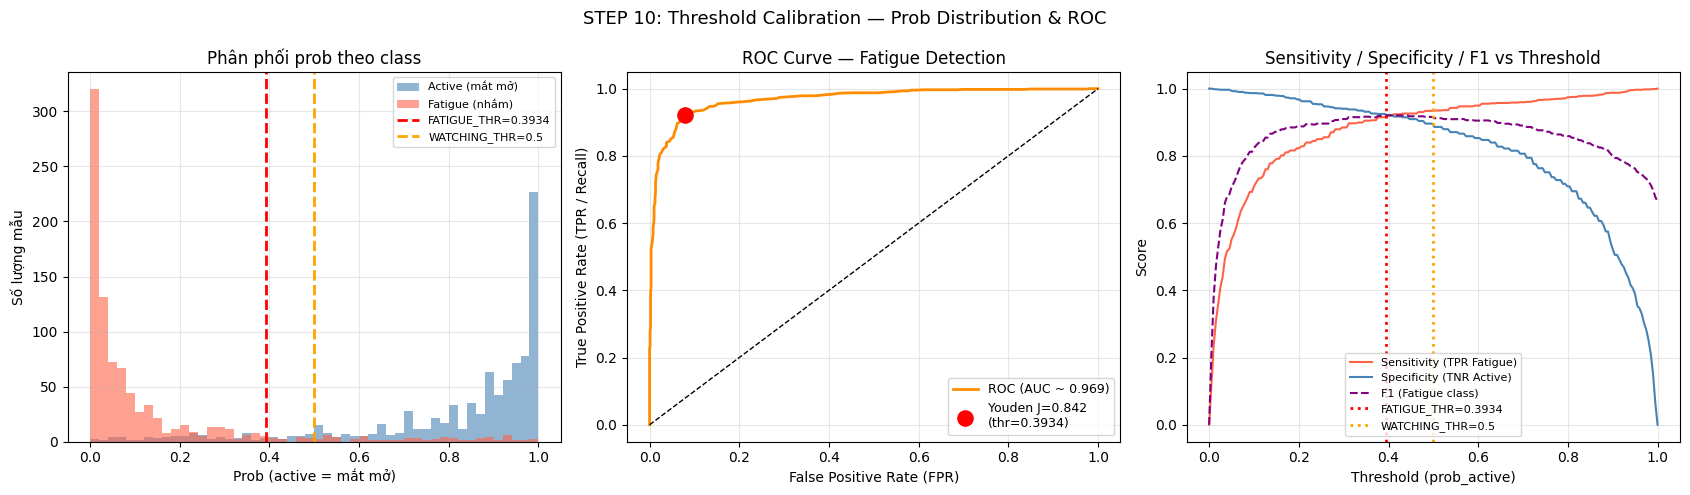

📊 Biểu đồ đã lưu: /content/drive/MyDrive/Colab Notebooks/DriverDrowsiness/Models/threshold_calibration.png

💾 Thresholds đã lưu: /content/drive/MyDrive/Colab Notebooks/DriverDrowsiness/Models/thresholds.json

════════════════════════════════════════════════════════════
  ✅ KẾT QUẢ CALIBRATION:
  FATIGUE_THRESHOLD  = 0.3934
  WATCHING_THRESHOLD = 0.5
════════════════════════════════════════════════════════════

  → Copy 2 giá trị trên vào realtime_cam.py
  → HOẶC dùng flag: python realtime_cam.py --calib thresholds.json
════════════════════════════════════════════════════════════



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# STEP 10: THRESHOLD CALIBRATION — Tự động tìm ngưỡng mở/nhắm mắt
# ═══════════════════════════════════════════════════════════════════════════
#
# Chạy TRONG COLAB sau STEP 9 (đã có tflite_path, X_test, y_test, inp_scale, inp_zp)
#
# Phương pháp:
#   1. Chạy toàn bộ X_test qua INT8 TFLite → thu thập prob của từng sample
#   2. Vẽ histogram phân phối prob theo class (0=Fatigue, 1=Active)
#   3. Tìm ngưỡng tối ưu bằng Youden's J (maximize sensitivity + specificity)
#   4. Gợi ý FATIGUE_THRESHOLD và WATCHING_THRESHOLD phù hợp thực tế
#   5. Xuất kết quả ra JSON để realtime_cam.py tự đọc
#
# Sau khi chạy step này, bạn sẽ thấy:
#   ✅ FATIGUE_THRESHOLD  = X.XX  ← dùng giá trị này trong realtime_cam.py
#   ✅ WATCHING_THRESHOLD = X.XX  ← dùng giá trị này trong realtime_cam.py
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import json, os
from sklearn.metrics import roc_curve, confusion_matrix, classification_report

# ── Đảm bảo các biến này đã có từ Step 9 ──────────────────────────────────
# tflite_path, X_test, y_test, inp_scale, inp_zp, out_scale, out_zp, interpreter
# input_details, output_details
# Nếu chạy lại độc lập, uncomment và điền lại:
# tflite_path = '/content/drive/MyDrive/.../drowsiness_asic_int8.tflite'
# interpreter = tf.lite.Interpreter(model_path=tflite_path)
# interpreter.allocate_tensors()
# ... (load lại như Step 9)

print("=" * 70)
print("STEP 10: THRESHOLD CALIBRATION")
print("=" * 70)
print("Mục tiêu: tìm ngưỡng prob phân chia MẮT MỞ / MẮT NHẮM tối ưu")
print("          để dùng trong realtime_cam.py\n")

# ══════════════════════════════════════════════════════════════════════
# 10.1 — Thu thập prob từ toàn bộ test set
# ══════════════════════════════════════════════════════════════════════
print("📊 Đang inference toàn bộ test set qua INT8 TFLite...")

probs_raw   = []   # prob từng sample
labels_true = []   # label thực (0=Fatigue/nhắm, 1=Active/mở)

# Đọc lại tất cả quant params trực tiếp — không phụ thuộc vào biến scope từ STEP 9
_inp_det   = interpreter.get_input_details()[0]
_out_det   = interpreter.get_output_details()[0]
_inp_scale = float(_inp_det['quantization_parameters']['scales'][0])
_inp_zp    = int(_inp_det['quantization_parameters']['zero_points'][0])
_out_scale = float(_out_det['quantization_parameters']['scales'][0])
_out_zp    = int(_out_det['quantization_parameters']['zero_points'][0])

print(f"  Input  scale={_inp_scale:.8f}, zp={_inp_zp}")
print(f"  Output scale={_out_scale:.8f}, zp={_out_zp}\n")

for i in range(len(X_test)):
    sample    = X_test[i:i+1].astype(np.float32)
    # Quantize float32 → int8 theo đúng scale/zp của model
    inp_int8  = np.round(sample / _inp_scale + _inp_zp).clip(-128, 127).astype(np.int8)

    interpreter.set_tensor(_inp_det['index'], inp_int8)
    interpreter.invoke()
    out       = interpreter.get_tensor(_out_det['index'])
    logit     = float((int(out[0][0]) - _out_zp) * _out_scale)
    prob      = 1.0 / (1.0 + np.exp(-logit))

    probs_raw.append(prob)
    labels_true.append(int(y_test[i]))

probs_raw   = np.array(probs_raw)
labels_true = np.array(labels_true)

# Tách prob theo class
prob_active  = probs_raw[labels_true == 1]   # Mắt mở → prob cao
prob_fatigue = probs_raw[labels_true == 0]   # Mắt nhắm → prob thấp

print(f"\n📊 Phân phối prob theo class:")
print(f"  Active  (mắt mở,  n={len(prob_active):4d}): mean={prob_active.mean():.4f}, "
      f"min={prob_active.min():.4f}, max={prob_active.max():.4f}")
print(f"  Fatigue (mắt nhắm,n={len(prob_fatigue):4d}): mean={prob_fatigue.mean():.4f}, "
      f"min={prob_fatigue.min():.4f}, max={prob_fatigue.max():.4f}")

# ══════════════════════════════════════════════════════════════════════
# 10.2 — Tìm ngưỡng tối ưu bằng ROC + Youden's J
# ══════════════════════════════════════════════════════════════════════
# ROC: labels_true=1 → Active (mắt mở) là "positive"
# → ta muốn detect Fatigue (=0) → đảo: label_fatigue = 1 - labels_true
labels_fatigue = 1 - labels_true   # 1=Fatigue (nhắm), 0=Active (mở)
scores_fatigue = 1.0 - probs_raw   # prob nhắm mắt = 1 - prob_active

fpr, tpr, roc_thresholds = roc_curve(labels_fatigue, scores_fatigue)
roc_auc = np.trapz(tpr, fpr) * (-1)   # AUC (fpr giảm dần → trapz âm)

# Youden's J = TPR - FPR → maximize → ngưỡng tốt nhất
youden_j  = tpr - fpr
best_idx  = np.argmax(youden_j)
best_thr_fatigue_score = roc_thresholds[best_idx]

# Chuyển ngược về prob_active (prob model output)
# scores_fatigue = 1 - prob → best_thr_prob = 1 - best_thr_fatigue_score
OPTIMAL_THRESHOLD = round(float(1.0 - best_thr_fatigue_score), 4)

# FATIGUE_THRESHOLD: dùng thẳng optimal threshold
# WATCHING_THRESHOLD: đặt cao hơn 1 mức để bắt "mắt nặng" sớm hơn
FATIGUE_THRESHOLD  = OPTIMAL_THRESHOLD
WATCHING_THRESHOLD = round(min(OPTIMAL_THRESHOLD * 2.5, OPTIMAL_THRESHOLD + 0.20, 0.50), 4)

# Đảm bảo không vượt quá các giới hạn hợp lý
FATIGUE_THRESHOLD  = max(0.01, min(FATIGUE_THRESHOLD,  0.45))
WATCHING_THRESHOLD = max(FATIGUE_THRESHOLD + 0.05,
                         min(WATCHING_THRESHOLD, 0.70))

print(f"\n✅ Youden's J optimal threshold (prob_active):")
print(f"   TPR={tpr[best_idx]:.4f}  FPR={fpr[best_idx]:.4f}  J={youden_j[best_idx]:.4f}")
print(f"\n🎯 Ngưỡng gợi ý cho realtime_cam.py:")
print(f"   FATIGUE_THRESHOLD  = {FATIGUE_THRESHOLD}")
print(f"   WATCHING_THRESHOLD = {WATCHING_THRESHOLD}")

# ── Tính accuracy tại ngưỡng tối ưu ──────────────────────────────────
preds_at_thr = (probs_raw >= OPTIMAL_THRESHOLD).astype(int)   # 1=Active, 0=Fatigue
cm = confusion_matrix(labels_true, preds_at_thr)

print(f"\n📊 Confusion matrix tại FATIGUE_THRESHOLD={FATIGUE_THRESHOLD}:")
print(f"         Pred Fatigue  Pred Active")
print(f"  True Fatigue   {cm[0,0]:5d}        {cm[0,1]:5d}")
print(f"  True Active    {cm[1,0]:5d}        {cm[1,1]:5d}")
print()
print(classification_report(labels_true, preds_at_thr,
                             target_names=['Fatigue(nhắm)', 'Active(mở)']))

# ══════════════════════════════════════════════════════════════════════
# 10.3 — Phân tích percentile để xác nhận ngưỡng
# ══════════════════════════════════════════════════════════════════════
print("📊 Percentile phân phối prob:")
pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99]
print(f"\n  {'Percentile':>12}  {'Fatigue prob':>14}  {'Active prob':>14}")
print(f"  {'─'*12}  {'─'*14}  {'─'*14}")
for p in pcts:
    pf = np.percentile(prob_fatigue, p)
    pa = np.percentile(prob_active, p)
    print(f"  {p:>11}%  {pf:>14.4f}  {pa:>14.4f}")

# Fatigue P95 và Active P5 → vùng an toàn để đặt ngưỡng
fat_p95 = np.percentile(prob_fatigue, 95)
act_p05 = np.percentile(prob_active,  5)
print(f"\n  Fatigue P95 (95% nhắm mắt nằm dưới) : {fat_p95:.4f}")
print(f"  Active  P5  (95% mở mắt nằm trên)   : {act_p05:.4f}")

# Nếu có overlap (fat_p95 > act_p05) → model khó phân biệt → cần xem xét lại data
if fat_p95 > act_p05:
    print(f"  ⚠️  Hai class bị OVERLAP (fat_p95 > act_p05)")
    print(f"      → Ngưỡng tối ưu vẫn dùng Youden's J")
else:
    print(f"  ✅ Hai class tách biệt rõ ràng")
    safe_low  = fat_p95
    safe_high = act_p05
    # Đề xuất ngưỡng bổ sung từ phân tích percentile
    candidate_thr = round((safe_low + safe_high) / 2, 4)
    print(f"  → Candidate từ percentile: {candidate_thr:.4f}  "
          f"(midpoint [{safe_low:.4f}, {safe_high:.4f}])")

# ══════════════════════════════════════════════════════════════════════
# 10.4 — Vẽ biểu đồ
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("STEP 10: Threshold Calibration — Prob Distribution & ROC", fontsize=13)

# --- Plot 1: Histogram phân phối prob theo class ---
ax = axes[0]
bins = np.linspace(0, 1, 51)
ax.hist(prob_active,  bins=bins, alpha=0.6, color='steelblue', label='Active (mắt mở)')
ax.hist(prob_fatigue, bins=bins, alpha=0.6, color='tomato',    label='Fatigue (nhắm)')
ax.axvline(FATIGUE_THRESHOLD,  color='red',    linestyle='--', linewidth=2,
           label=f'FATIGUE_THR={FATIGUE_THRESHOLD}')
ax.axvline(WATCHING_THRESHOLD, color='orange', linestyle='--', linewidth=2,
           label=f'WATCHING_THR={WATCHING_THRESHOLD}')
ax.set_xlabel('Prob (active = mắt mở)')
ax.set_ylabel('Số lượng mẫu')
ax.set_title('Phân phối prob theo class')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Plot 2: ROC curve ---
ax = axes[1]
ax.plot(fpr, tpr, color='darkorange', lw=2,
        label=f'ROC (AUC ~ {abs(roc_auc):.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.scatter(fpr[best_idx], tpr[best_idx], s=120, color='red', zorder=5,
           label=f'Youden J={youden_j[best_idx]:.3f}\n(thr={FATIGUE_THRESHOLD})')
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR / Recall)')
ax.set_title('ROC Curve — Fatigue Detection')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 3: Sensitivity / Specificity vs Threshold ---
ax = axes[2]
thr_sweep = np.linspace(0.0, 1.0, 200)
sens_arr, spec_arr, f1_arr = [], [], []

for thr in thr_sweep:
    preds = (probs_raw >= thr).astype(int)
    tp = ((preds == 0) & (labels_true == 0)).sum()   # detect fatigue đúng
    tn = ((preds == 1) & (labels_true == 1)).sum()   # detect active đúng
    fp = ((preds == 0) & (labels_true == 1)).sum()   # nhầm active → fatigue
    fn = ((preds == 1) & (labels_true == 0)).sum()   # bỏ qua fatigue
    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    f1   = 2 * prec * sens / (prec + sens + 1e-9)
    sens_arr.append(sens)
    spec_arr.append(spec)
    f1_arr.append(f1)

ax.plot(thr_sweep, sens_arr, label='Sensitivity (TPR Fatigue)', color='tomato')
ax.plot(thr_sweep, spec_arr, label='Specificity (TNR Active)',  color='steelblue')
ax.plot(thr_sweep, f1_arr,   label='F1 (Fatigue class)',        color='purple',
        linestyle='--')
ax.axvline(FATIGUE_THRESHOLD,  color='red',    linestyle=':', linewidth=2,
           label=f'FATIGUE_THR={FATIGUE_THRESHOLD}')
ax.axvline(WATCHING_THRESHOLD, color='orange', linestyle=':', linewidth=2,
           label=f'WATCHING_THR={WATCHING_THRESHOLD}')
ax.set_xlabel('Threshold (prob_active)')
ax.set_ylabel('Score')
ax.set_title('Sensitivity / Specificity / F1 vs Threshold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
calib_plot_path = os.path.join(OUTPUT_PATH, 'threshold_calibration.png')
plt.savefig(calib_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Biểu đồ đã lưu: {calib_plot_path}")

# ══════════════════════════════════════════════════════════════════════
# 10.5 — Xuất JSON để realtime_cam.py tự đọc
# ══════════════════════════════════════════════════════════════════════
calib_result = {
    "FATIGUE_THRESHOLD":  FATIGUE_THRESHOLD,
    "WATCHING_THRESHOLD": WATCHING_THRESHOLD,
    "youden_j":           round(float(youden_j[best_idx]), 4),
    "tpr_at_threshold":   round(float(tpr[best_idx]), 4),
    "fpr_at_threshold":   round(float(fpr[best_idx]), 4),
    "prob_fatigue_mean":  round(float(prob_fatigue.mean()), 4),
    "prob_active_mean":   round(float(prob_active.mean()), 4),
    "prob_fatigue_p95":   round(float(fat_p95), 4),
    "prob_active_p05":    round(float(act_p05), 4),
    "n_samples":          int(len(probs_raw)),
    "model_path":         tflite_path,
}

calib_json_path = os.path.join(OUTPUT_PATH, 'thresholds.json')
with open(calib_json_path, 'w') as f:
    json.dump(calib_result, f, indent=2)

print(f"\n💾 Thresholds đã lưu: {calib_json_path}")
print(f"\n{'═'*60}")
print(f"  ✅ KẾT QUẢ CALIBRATION:")
print(f"  FATIGUE_THRESHOLD  = {FATIGUE_THRESHOLD}")
print(f"  WATCHING_THRESHOLD = {WATCHING_THRESHOLD}")
print(f"{'═'*60}")
print(f"\n  → Copy 2 giá trị trên vào realtime_cam.py")
print(f"  → HOẶC dùng flag: python realtime_cam.py --calib thresholds.json")
print(f"{'═'*60}\n")

STEP 11: TRAINING REPORT

📋 Layer-by-layer architecture:
#    Layer                           Output shape            Params
----------------------------------------------------------------------
0    input_q07                       []                           0
1    dw_conv1                        (32, 32, 1)                  9
2    pw_conv1                        (32, 32, 16)                16
3    bn1                             (32, 32, 16)                64
4    relu1                           (32, 32, 16)                 0
5    dw_conv2                        (16, 16, 16)               144
6    pw_conv2                        (16, 16, 32)               512
7    bn2                             (16, 16, 32)               128
8    relu2                           (16, 16, 32)                 0
9    dw_conv3                        (8, 8, 32)                 288
10   pw_conv3                        (8, 8, 64)               2,048
11   bn3                             (8, 8, 64)         

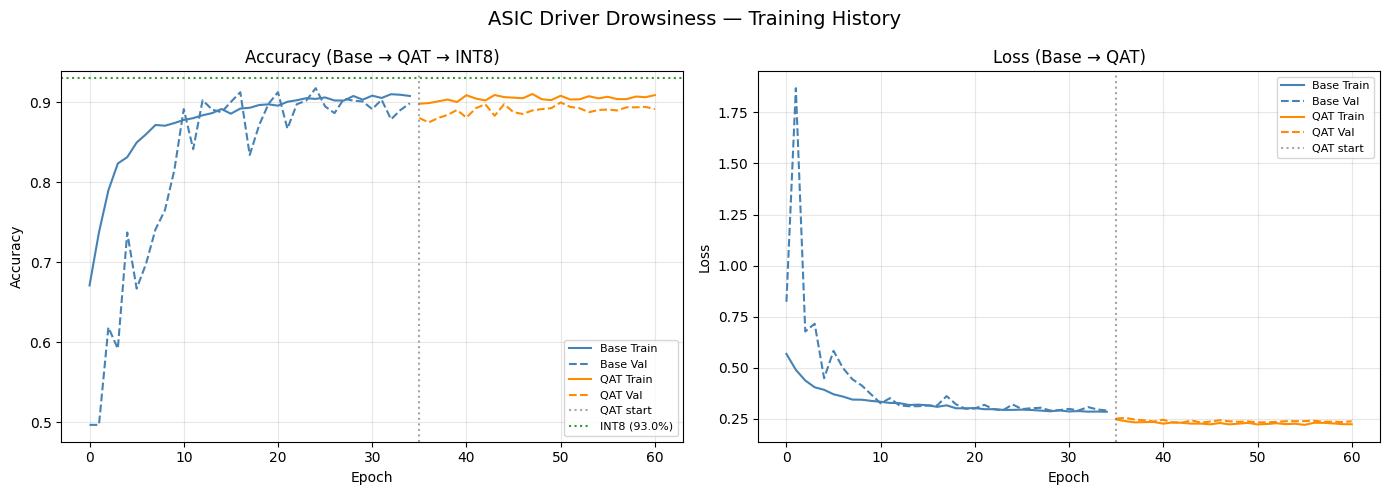

📊 Biểu đồ đã lưu: training_history.png

✅ COMPLETE QAT PIPELINE HOÀN THÀNH!
📁 Output files: /content/drive/MyDrive/Colab Notebooks/DriverDrowsiness/Models
  • base_weights.weights.h5
  • qat_weights.weights.h5
  • drowsiness_asic_int8.tflite
  • asic_weights.h
  • training_history.png


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# STEP 11: TRAINING REPORT + BIỂU ĐỒ
# ═══════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("STEP 11: TRAINING REPORT")
print("=" * 70)

print("\n📋 Layer-by-layer architecture:")
print(f"{'#':<3}  {'Layer':<30}  {'Output shape':<20}  {'Params':>8}")
print("-" * 70)
for idx, layer in enumerate(base_model.layers):
    try:
        out_shape = str(layer.output_shape[1:])
    except Exception:
        out_shape = "N/A"
    n_params = layer.count_params()
    print(f"{idx:<3}  {layer.name:<30}  {out_shape:<20}  {n_params:>8,}")

def last(hist, key):
    return hist.history[key][-1]

print(f"\n{'─'*50}")
print(f"FINAL RESULTS SUMMARY")
print(f"{'─'*50}")

print(f"\n[Base Model — Float32]")
print(f"  Train accuracy : {last(history_base,'accuracy')*100:.2f}%")
print(f"  Val accuracy   : {last(history_base,'val_accuracy')*100:.2f}%")

if QAT_AVAILABLE:
    print(f"\n[QAT Model — Fake-Quant]")
    print(f"  Train accuracy : {last(history_qat,'accuracy')*100:.2f}%")
    print(f"  Val accuracy   : {last(history_qat,'val_accuracy')*100:.2f}%")

print(f"\n[INT8 TFLite — ASIC Target]")
print(f"  INT8 accuracy  : {int8_acc:.2f}%")
print(f"  Model size     : {len(tflite_model)/1024:.1f} KB")

# Biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ASIC Driver Drowsiness — Training History", fontsize=14)

ax = axes[0]
ax.plot(history_base.history['accuracy'],     label='Base Train', color='steelblue')
ax.plot(history_base.history['val_accuracy'], label='Base Val',   color='steelblue', linestyle='--')
if QAT_AVAILABLE:
    offset = len(history_base.history['accuracy'])
    epochs_qat = range(offset, offset + len(history_qat.history['accuracy']))
    ax.plot(epochs_qat, history_qat.history['accuracy'],     label='QAT Train', color='darkorange')
    ax.plot(epochs_qat, history_qat.history['val_accuracy'], label='QAT Val',   color='darkorange', linestyle='--')
    ax.axvline(x=offset, color='gray', linestyle=':', alpha=0.7, label='QAT start')
ax.axhline(y=int8_acc/100, color='green', linestyle=':', alpha=0.8, label=f'INT8 ({int8_acc:.1f}%)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_title('Accuracy (Base → QAT → INT8)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(history_base.history['loss'],     label='Base Train', color='steelblue')
ax.plot(history_base.history['val_loss'], label='Base Val',   color='steelblue', linestyle='--')
if QAT_AVAILABLE:
    ax.plot(epochs_qat, history_qat.history['loss'],     label='QAT Train', color='darkorange')
    ax.plot(epochs_qat, history_qat.history['val_loss'], label='QAT Val',   color='darkorange', linestyle='--')
    ax.axvline(x=offset, color='gray', linestyle=':', alpha=0.7, label='QAT start')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Loss (Base → QAT)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'training_history.png'), dpi=150)
plt.show()
print("📊 Biểu đồ đã lưu: training_history.png")

print("\n" + "=" * 70)
print("✅ COMPLETE QAT PIPELINE HOÀN THÀNH!")
print("=" * 70)
print(f"📁 Output files: {OUTPUT_PATH}")
print(f"  • base_weights.weights.h5")
if QAT_AVAILABLE:
    print(f"  • qat_weights.weights.h5")
print(f"  • drowsiness_asic_int8.tflite")
print(f"  • asic_weights.h")
print(f"  • training_history.png")